# Assignment 3

Written by Kira Damo
Due March 2nd, 2026

# Part 1

## Question A

### Loading Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [2]:
communities_df = pd.read_csv('/Users/kiradamo/Documents/DSC 478/communities/communities.csv')

In [3]:
communities_df.head()

,state,communityname,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop
0,8,Lakewoodcity,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,...,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.20
1,53,Tukwilacity,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,...,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.67
2,24,Aberdeentown,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,...,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.43
3,34,Willingborotownship,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,...,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.12
4,42,Bethlehemtownship,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,...,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.03


The target attribute for regression is ViolentCrimesPerPop. State and community name must be excluded for the regression model.

In [4]:
communities_df = communities_df.drop(columns=['state', 'communityname'])
communities_df

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.00,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.00,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.00,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.00,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.00,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.00,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.00,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.02,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.01,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.19


### Handling Missing Values

Like previous assignments, NaN values are replaced with a '?'. These values will need to be replaced with the average.

In [5]:
communities_df[communities_df.isin(["?"]).any(axis=1)]

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop
130,0.02,0.38,0.98,0.22,0.01,0.01,0.44,0.4,0.27,0.58,...,0.0,0.01,0.84,0.7,0.83,0.77,0.04,0.12,0.05,0.23


In [6]:
communities_df = communities_df.replace('?', np.nan)

In [7]:
communities_df.isna().sum()[communities_df.isna().sum() > 0]

OtherPerCap    1
dtype: int64

In [8]:
communities_df['OtherPerCap']= pd.to_numeric(communities_df['OtherPerCap'], errors='coerce')

In [9]:
communities_df['OtherPerCap']= pd.to_numeric(communities_df['OtherPerCap'], errors='coerce')
avg_OPC = communities_df['OtherPerCap'].mean(skipna=True)
communities_df['OtherPerCap'] = communities_df['OtherPerCap'].fillna(avg_OPC)

In [10]:
communities_df[communities_df.isin(["?"]).any(axis=1)]

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop


### Train, Test, Split

Since ViolentCrimesPerPop is our target attribute, that will be separated into Y and all other features excluding ViolentCrimesPerPop will be X

In [11]:
y = communities_df['ViolentCrimesPerPop']
X = communities_df.drop(columns = 'ViolentCrimesPerPop')
X

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.04,0.00,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.00,0.00,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.00,0.00,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.00,0.00,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.00,0.00,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.00,0.00,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.01,0.00,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.06,0.02,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.04,0.01,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33


In [12]:
y

0       0.20
1       0.67
2       0.43
3       0.12
4       0.03
        ... 
1989    0.09
1990    0.45
1991    0.23
1992    0.19
1993    0.48
Name: ViolentCrimesPerPop, Length: 1994, dtype: float64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)
print(f'Training Shape: {X_train.shape}')
print(f'Testing Shape: {X_test.shape}')

Training Shape: (1595, 97)
Testing Shape: (399, 97)


## Question B

### Predicted vs Actual (Training)

In [14]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
pred = linreg.predict(X_test)

In [16]:
# p_train is the array of predicted values
p_train = linreg.predict(X_train)
# array of errors
err_train = abs(p_train - y_train)
# dot protect of itself = sum of squared errors
sum_sq_err = np.dot(err_train,err_train)
# RMSE of of training data
rmse_train = np.sqrt(sum_sq_err/len(p_train))
print(f'RMSE on Training Data: {rmse_train}')

RMSE on Training Data: 0.1261959313342669


In [17]:
import pylab as pl

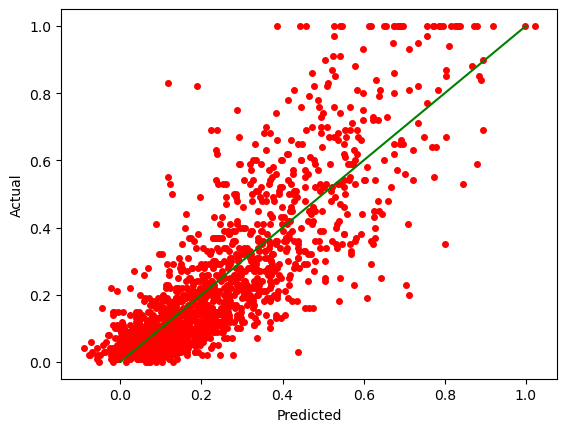

In [18]:
%matplotlib inline
pl.plot(p_train, y_train,'ro', markersize=4)
pl.plot([0,1],[0,1], 'g-')
pl.xlabel('Predicted')
pl.ylabel('Actual')
pl.show()

### Regression Coefficients

In [19]:
#regression coefficients (weights)
w = linreg.coef_
for i in range(len(X_train.columns)):
    print("%7s   %2.7f" % (X_train.columns[i], linreg.coef_[i]))

population   -0.0075266
householdsize   -0.0528397
racepctblack   0.2215476
racePctWhite   -0.0503199
racePctAsian   -0.0196010
racePctHisp   0.0476950
agePct12t21   0.1022852
agePct12t29   -0.1698965
agePct16t24   -0.1262115
agePct65up   0.0714205
numbUrban   -0.1258533
pctUrban   0.0387986
medIncome   -0.2019181
pctWWage   -0.2131219
pctWFarmSelf   0.0421247
pctWInvInc   -0.0744446
pctWSocSec   0.0124852
pctWPubAsst   0.0225201
pctWRetire   -0.0958013
medFamInc   0.3539796
perCapInc   0.0757327
whitePerCap   -0.3520899
blackPerCap   -0.0293676
indianPerCap   -0.0415894
AsianPerCap   0.0333221
OtherPerCap   0.0471029
HispPerCap   0.0389022
NumUnderPov   0.2977708
PctPopUnderPov   -0.2385513
PctLess9thGrade   -0.0085328
PctNotHSGrad   -0.0453960
PctBSorMore   0.0767420
PctUnemployed   0.0156572
PctEmploy   0.2250517
PctEmplManu   -0.0497874
PctEmplProfServ   -0.0391367
MalePctDivorce   0.3461948
MalePctNevMarr   0.2117273
FemalePctDiv   0.0754492
TotalPctDiv   -0.3591211
PersPerFam   -

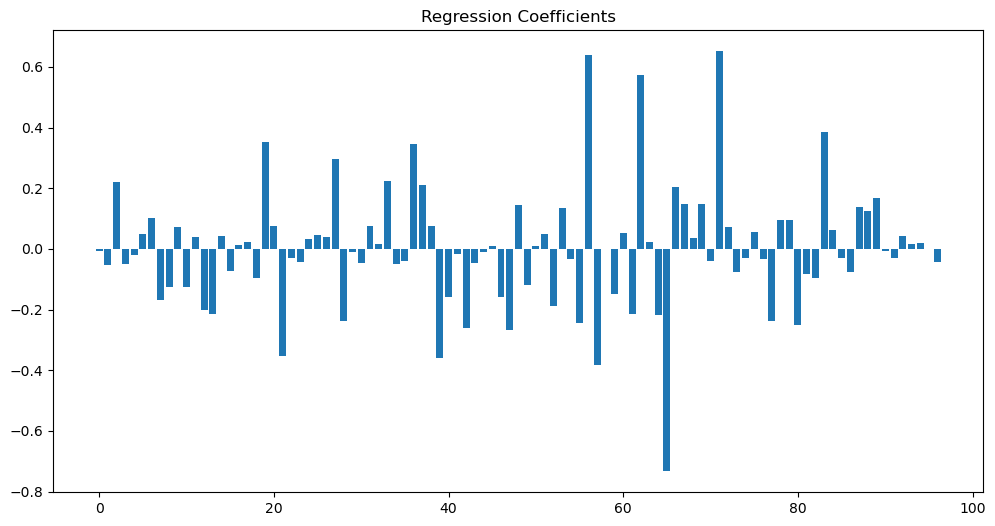

In [20]:
#bar chart of all the weights/coefficients
pl.figure(figsize=(12,6))
pl.bar(range(len(linreg.coef_)), linreg.coef_)
pl.title("Regression Coefficients")
pl.show()

### 10-Fold Cross-Validation

In [21]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold    

In [22]:
def cross_validate(model, X, y, n, verbose=True):
    # model: regression model to be trained
    # X: the training data matrix
    # y: the training target variable array
    # n: the number of fold for x-validation
    # Returns mean RMSE across all folds
    kf = KFold(n_splits=n, random_state=33,shuffle=True)
    # specifying random_state ensures the same random
    # partitions are used across different runs
    xval_err = 0
    f = 1
    for train,test in kf.split(X):
        model.fit(X.iloc[train],y.iloc[train]) # fit model to the training partition in this fold
        p_test = model.predict(X.iloc[test]) # apply trained model to test partition in this fold
        rmse_test = np.sqrt(mean_squared_error(p_test, y.iloc[test]))
        if verbose:
            print("Fold %2d RMSE: %.4f" % (f, rmse_test))
        xval_err += rmse_test
        f += 1
    return xval_err/n

In [23]:
rmse_10cv = cross_validate(linreg, X_train, y_train, 10, verbose=True)
rmse_10cv

Fold  1 RMSE: 0.1433
Fold  2 RMSE: 0.1425
Fold  3 RMSE: 0.1439
Fold  4 RMSE: 0.1210
Fold  5 RMSE: 0.1320
Fold  6 RMSE: 0.1669
Fold  7 RMSE: 0.1173
Fold  8 RMSE: 0.1442
Fold  9 RMSE: 0.1225
Fold 10 RMSE: 0.1124


0.13460820375825625

In [24]:
print(f'Training RMSE: {rmse_train}\n10-Fold Cross Validation RMSE: {rmse_10cv}')
print(f'Difference between RMSE\'s: {abs(rmse_train - rmse_10cv)}')

Training RMSE: 0.1261959313342669
10-Fold Cross Validation RMSE: 0.13460820375825625
Difference between RMSE's: 0.008412272423989342


The training RMSE is lower than the 10-fold cross validation.The RMSE difference between the cross validation and training data is low (< 0.1). This indicates the cross validation model is not over or underfitting the training data and is generalizing adequately. 

## Question C

In [25]:
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.model_selection import cross_val_score

In [26]:
def feature_selection(X, y, model):
    percentiles = range(5, 101, 5)
    cv_scores = []
    for p in percentiles:
        fs = SelectPercentile(score_func=f_regression, percentile=p)
        X_train_fs = fs.fit_transform(X, y)

        scores = cross_val_score(model, X_train_fs, y, cv=5, scoring='neg_root_mean_squared_error')
        cv_scores.append(-scores.mean())

        best_percentile = percentiles[np.argmin(cv_scores)]

    plt.plot(percentiles, cv_scores)
    plt.xlabel("Percentile of Features")
    plt.ylabel("CV RMSE")
    plt.title("Feature Selection")
    plt.show()

    best_percentile = percentiles[np.argmin(cv_scores)]
    print("Best Percentile:", best_percentile)

    return best_percentile

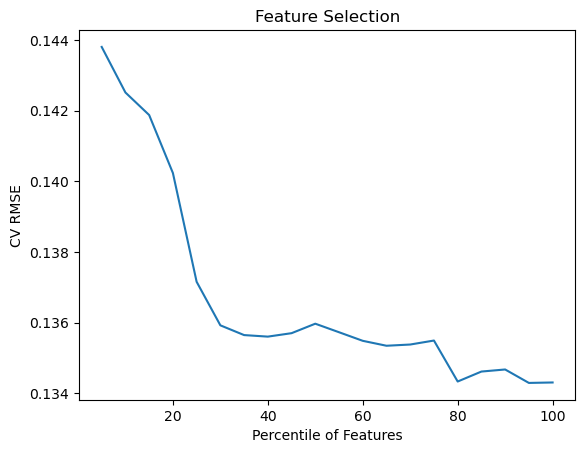

Best Percentile: 95


In [27]:
best_p = feature_selection(X_train, y_train, LinearRegression())

In [28]:
#using best percentile to find and display the best features
best_fs = SelectPercentile(f_regression, percentile=best_p)
X_train_p = best_fs.fit_transform(X_train, y_train)
X_test_selected = best_fs.transform(X_test)
linreg.fit(X_train_p, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
#printing all best features and their statistical scores
selected_features = X_train.columns[best_fs.get_support()]
for sf, score in zip(selected_features, best_fs.scores_):
    print(sf, score)

population 256.0323547372106
householdsize 3.492519416199998
racepctblack 1074.8895092675327
racePctWhite 1412.5078123924097
racePctHisp 1.9595906311025277
agePct12t21 137.54043215677996
agePct12t29 4.894803532795904
agePct16t24 37.33401496511396
agePct65up 15.875055643949562
numbUrban 8.247938405545224
pctUrban 247.77613854814723
medIncome 11.060895847737816
pctWWage 341.63253752319184
pctWFarmSelf 161.57075094157
pctWInvInc 40.34422029878605
pctWSocSec 756.0149723312646
pctWPubAsst 22.48637906817393
pctWRetire 784.5706408092445
medFamInc 13.975623750024441
perCapInc 366.90042184405894
whitePerCap 214.99315799068754
blackPerCap 65.4462345492273
indianPerCap 126.57709861890277
AsianPerCap 12.317095444554923
OtherPerCap 29.069227068932697
HispPerCap 33.36930259404439
NumUnderPov 92.36570683066233
PctPopUnderPov 400.3078568907917
PctLess9thGrade 578.817365213768
PctNotHSGrad 319.21810810192324
PctBSorMore 472.1962078690574
PctUnemployed 173.36684318428422
PctEmploy 533.9131521991867
PctE

In [30]:
y_test_pred = linreg.predict(X_test_selected)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE with selected features:", test_rmse)

Test RMSE with selected features: 0.14357528582006165


The test data's RMSE is still relatively close to the training RMSE and the 10-fold cross validation RMSE indicating this model is also not overfitting or underfitting.

## Question D

In [31]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [32]:
def model_selection(model_class, X, y, alphas, k):
    t_rmse = np.array([])
    cv_rmse = np.array([])
    alpha = np.linspace(0,1,100)

    for a in alphas:
        model = model_class(alpha=a)
        model.fit(X, y)
        p_train = model.predict(X)
        
        rmse_train = np.sqrt(mean_squared_error(p_train, y))
        rmse_cv = cross_validate(model, X_train, y_train, n=k, verbose=False)
    
        t_rmse = np.append(t_rmse, [rmse_train])
        cv_rmse = np.append(cv_rmse, [rmse_cv])

    best_idx = np.argmin(cv_rmse)
    best_alpha = alphas[best_idx]

    plt.figure(figsize=(8,5))
    plt.plot(alphas, t_rmse, marker='o', label='Training RMSE')
    plt.plot(alphas, cv_rmse, marker='s', label='CV RMSE')
    plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best alpha = {best_alpha:.3f}')
    plt.xscale('log')
    plt.xlabel('Alpha')
    plt.ylabel('RMSE')
    plt.title(f'Model Selection for {model_class.__name__}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"{model_class.__name__} - Best alpha: {best_alpha:.3f}, Test RMSE: {test_rmse:.3f}")
    

    return best_alpha, t_rmse, cv_rmse

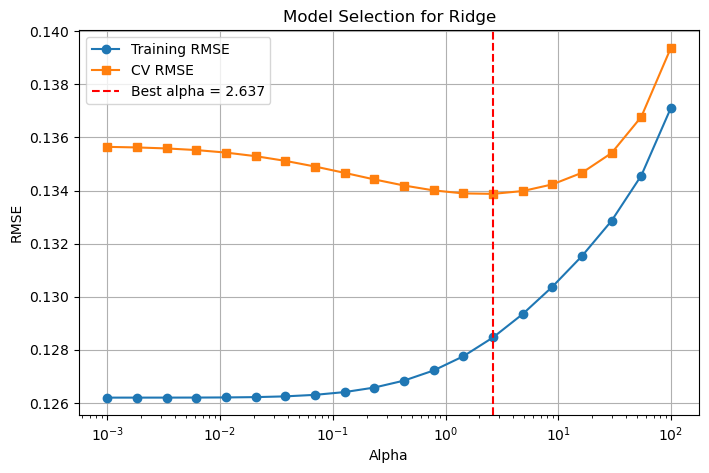

Ridge - Best alpha: 2.637, Test RMSE: 0.144


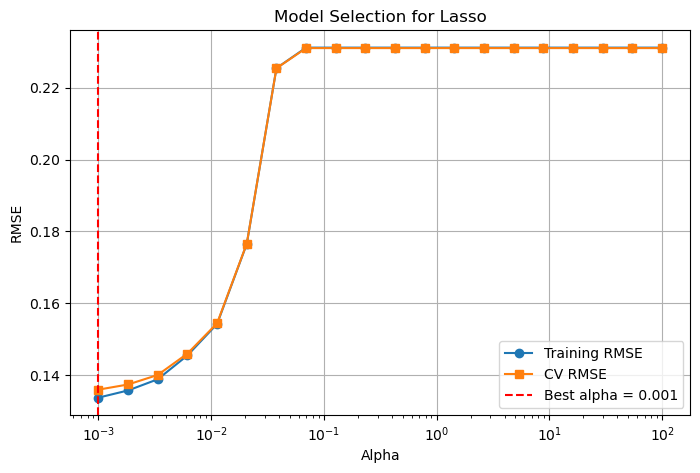

Lasso - Best alpha: 0.001, Test RMSE: 0.144


In [33]:
alphas = np.logspace(-3, 2, 20)  # 0.001 to 100

best_alpha_ridge, t_rmse_ridge, cv_rmse_ridge = model_selection(Ridge, X_train, y_train, alphas, k=5)

best_alpha_lasso, t_rmse_lasso, cv_rmse_lasso = model_selection(Lasso, X_train, y_train, alphas, k=5)


The Ridge Regression cross-validation creates a shallow U-shape showing the bias-variance tradeoff. The best alpha value is the minimum RMSE of Ridge Regression cross-validation. The moderate regularization value of ~2.637 minimizes error and improves performance.

The Lasso regression curve steeply increases as alpha increases. The best alpha value is very small (close to 0). If regularization were to be stronger, then the model would be underfitting predictions. This suggests that minimal regularization is best for this dataset. 

## Question E

In [34]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [35]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

param_grid = {
    'penalty': ['l1', 'l2'],
    'alpha': np.logspace(-4, 1, 10) #0.0001 - 10
}

sgdreg = SGDRegressor(random_state=33)

gs = GridSearchCV(
    estimator=sgdreg,
    param_grid = param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5
)

gs.fit(X_train_s, y_train)

print("Best parameters:", gs.best_params_)

Best parameters: {'alpha': 0.001291549665014884, 'penalty': 'l1'}


### Best Parameters

In [36]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

param_grid_best = {
    'penalty': ['l1'],
    'alpha': [0.001291549665014884] #0.0001 - 10
}

sgdreg = SGDRegressor(random_state=33)

gs_best = GridSearchCV(
    estimator=sgdreg,
    param_grid = param_grid_best,
    scoring='neg_root_mean_squared_error',
    cv=5
)

gs_best.fit(X_train_s, y_train)


,estimator,SGDRegressor(random_state=33)
,param_grid,"{'alpha': [0.001291549665014884], 'penalty': ['l1']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [37]:
y_train_pred = gs_best.predict(X_train_s)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = gs_best.predict(X_test_s)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
test_rmse - train_rmse

Training RMSE: 0.13207451832019645
Test RMSE: 0.14653564513958434


0.014461126819387882

The best parameters produced RMSE scores that are less than 0.1 of each other. The model generalizes well on unseen data. The RMSE does not show signs of over or underfitting the data.

### Elastic Net

In [38]:
from sklearn.linear_model import ElasticNet

In [39]:
param_grid_en = {
    'l1_ratio': np.linspace(0, 1, 10),
    'alpha': np.logspace(-4, 1, 10) #0.0001 - 10
}

sgdreg_en = SGDRegressor(penalty='elasticnet',random_state=33)

gs_en = GridSearchCV(
    estimator=sgdreg_en,
    param_grid = param_grid_en,
    scoring='neg_root_mean_squared_error',
    cv=5
)

gs_en.fit(X_train_s, y_train)
print("Best parameters:", gs_en.best_params_)

Best parameters: {'alpha': 0.004641588833612782, 'l1_ratio': 0.5555555555555556}


In [40]:
y_train_pred = gs_en.predict(X_train_s)
y_test_pred = gs_en.predict(X_test_s)  # make sure test set is scaled too

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Training RMSE: 0.1329138964434699
Test RMSE: 0.14605913193221778


The Elastic Net model produced training and testing RMSE's that are similar to both Ridge and Lasso. Elastic Net serves as a combination of Ridge and Lasso. The difference between all three models being small indicates that all three models generalize well and the models do not over or underfit the predictions.

# Part 2

## Question A

In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [42]:
#Reading Data
raw_data = pd.read_csv('/Users/kiradamo/Documents/DSC 478/BBC_News_5_Categories/bbc-5categories.csv')
#document term matrix
TF = pd.read_csv('/Users/kiradamo/Documents/DSC 478/BBC_News_5_Categories/BBC_News_5_TF.csv', index_col=0)
#terms
features = pd.read_csv('/Users/kiradamo/Documents/DSC 478/BBC_News_5_Categories/BBC_News_5_Features.csv', header=None)
#class labels for categorization
classes = pd.read_csv('/Users/kiradamo/Documents/DSC 478/BBC_News_5_Categories/BBC_News_5_Classes.csv', header=None)

In [43]:
raw_data

,doc_id,title,category,cat_id,text
0,0,Ad sales boost Time Warner profit,business,0,Quarterly profits at US media giant TimeWarner...
1,1,Dollar gains on Greenspan speech,business,0,The dollar has hit its highest level against t...
2,2,Yukos unit buyer faces loan claim,business,0,The owners of embattled Russian oil giant Yuko...
3,3,High fuel prices hit BA's profits,business,0,British Airways has blamed high fuel prices fo...
4,4,Pernod takeover talk lifts Domecq,business,0,Shares in UK drinks and food firm Allied Domec...
...,...,...,...,...,...
2220,2220,BT program to beat dialler scams,tech,4,BT is introducing two initiatives to help beat...
2221,2221,Spam e-mails tempt net shoppers,tech,4,Computer users across the world continue to ig...
2222,2222,Be careful how you code,tech,4,A new European directive could put software wr...
2223,2223,US cyber security chief resigns,tech,4,The man making sure US computer networks are s...


In [44]:
doc_ids = raw_data['doc_id'].values
titles = raw_data['title'].values
labels = raw_data['category'].values

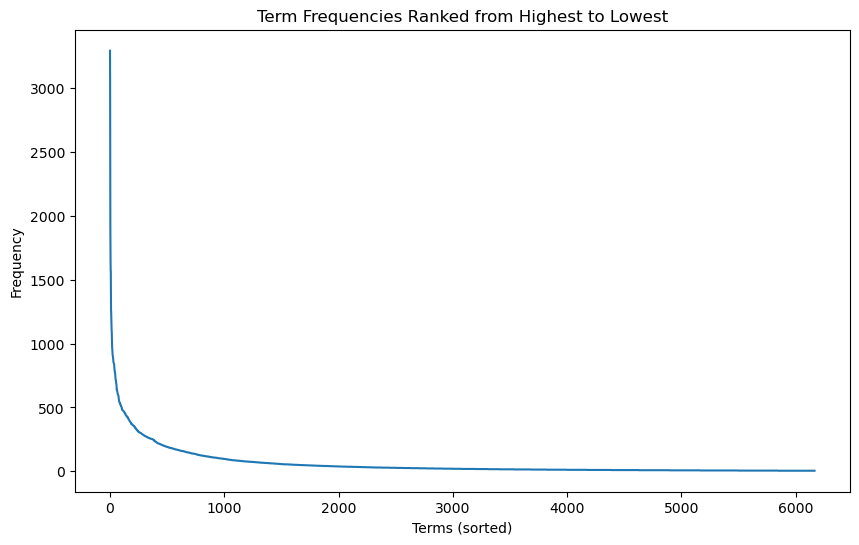

In [45]:
TF_sum = np.sum(TF, axis=0)
sorted_terms = np.sort(TF_sum)[::-1]

plt.figure(figsize=(10,6))
plt.plot(sorted_terms)
plt.title("Term Frequencies Ranked from Highest to Lowest")
plt.xlabel("Terms (sorted)")
plt.ylabel("Frequency")
plt.show()

In [77]:
#splitting data
#training and testing data for terms, labels, doc id, and titles
X_train, X_test, y_train, y_test, ids_train, ids_test, titles_train, titles_test = train_test_split(TF, labels, doc_ids, titles, test_size=0.2, random_state=99)

## Question B

In [78]:
import sys
sys.path.append("/Users/kiradamo/Documents/DSC 478")
import K_Means

In [79]:
from K_Means import kmeans

In [80]:
X_train_array = np.array(X_train)
clusters, centroids = kmeans(X_train_array, K=3, max_iterations=20, metric='cosine', mask_zeros=True)
unique, counts = np.unique(clusters, return_counts=True)
for c, count in zip(unique, counts):
    print(f"Cluster {c}: {count} documents")

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Cluster 0: 1036 documents
Cluster 1: 411 documents
Cluster 2: 333 documents


In [81]:
def display_clusters(clusters, doc_ids, titles, labels):
    unique_clusters = np.unique(clusters)
    for c in unique_clusters:
        print(f'Cluster: {c}')
        indices = np.where(clusters == c)[0]
        print(f"{'Doc ID':<10} {'Title':<40} {'Original Category':<20}")
        print("-"*70)
        for idx in indices:
            print(f"{str(doc_ids[idx]):<10} {titles[idx][:68]:<40} {labels[idx]:<20}")
        
display_clusters(clusters, ids_train, titles_train, y_train)

Cluster: 0
Doc ID     Title                                    Original Category   
----------------------------------------------------------------------
105        Golden rule 'intact' says ex-aide        business            
1948       The Force is strong in Battlefront       tech                
846        Career honour for actor DiCaprio         entertainment       
819        BBC denies Blackadder TV comeback        entertainment       
722        TV show unites Angolan families          entertainment       
960        Guantanamo pair's passport ban           politics            
1531       Hearts of Oak 3-2 Cotonsport             sport               
1653       Charvis set to lose fitness bid          sport               
1423       Bridge could miss rest of season         sport               
994        Blair stresses prosperity goals          politics            
1142       Kennedy to make temple address           politics            
1641       Umaga ready for "fearsome" Lion

## Question C

In [95]:
from K_Means import cluster_sizes, display_centroids

In [100]:
clusters, centroids = kmeans(X_train_array, K=3, max_iterations=20, metric='cosine', mask_zeros=True)
c_size = cluster_sizes(X_train, clusters)
for c, sz in c_size.items():
    print(f"Cluster {c} size: {sz}")

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Cluster 0 size: 977
Cluster 1 size: 435
Cluster 2 size: 368


In [102]:
centDF = display_centroids(centroids, features)
centDF

,aaa,aaron,abandon,abba,abbott,abc,abid,abil,abl,abn,...,zach,zealand,zeppelin,zero,zhang,zimbabw,zombi,zone,zoom,zurich
0,1.33,1.00,1.00,1.00,1.00,1.17,1.14,1.08,1.20,1.00,...,1.25,1.54,0.00,1.00,1.00,1.00,1.00,1.12,0.00,1.00
1,1.00,1.00,1.12,2.33,1.00,2.40,1.00,1.06,1.17,2.50,...,0.00,1.88,1.00,1.00,0.00,1.00,2.00,1.75,0.00,1.00
2,1.00,1.00,2.00,5.00,2.00,0.00,1.00,1.16,1.24,0.00,...,0.00,1.00,0.00,1.00,0.00,1.50,2.00,1.00,1.00,1.00


In [103]:
top_terms_cluster_0 = centDF.iloc[0].nlargest(10)  # top 10 terms for cluster 0
print(top_terms_cluster_0)

lg          7.33
aol         7.00
pvr         7.00
cont        6.83
yuko        6.65
hybrid      6.50
suv         6.00
turkey      5.38
casino      5.33
bollywood   5.00
Name: 0, dtype: float64


In [105]:
print(type(features))

<class 'list'>


Defining the function with parameters as the training data, the clusters obtained from kmeans, the features, and the N terms.

In [145]:
def cluster_analysis(data, clusters, centroids, features, N=10):
    unique_clusters = np.unique(clusters)

    #calculating the cluster sizes with cluster size function
    unique_clusters = np.unique(clusters)
    cluster_sizes_dict = { c: np.sum(clusters == c) for c in np.unique(clusters) }
    for c in unique_clusters:
        cluster_docs = data[clusters == c]
        centroid = centroids[c]   

        df_percentages = np.sum(cluster_docs > 0, axis=0) / cluster_docs.shape[0] * 100
        valid_indices = np.where(df_percentages > 0)[0] #only occuring documents

        sorted_indices = valid_indices[np.argsort(centroid[valid_indices])[::-1]]
        top_indices = sorted_indices[:N]

        print(f"CLUSTER {c} | Size: {cluster_sizes_dict[c]}")
        print(f"{'Term':<20} {'Freq':<12} {'DF':<10} {'% of Docs':<8}")

        for idx in top_indices:
            term = features[idx]  # get the term name
            mean_freq = centroid[idx]  # centroid weight
            df_count = np.sum(cluster_docs[:, idx] > 0)  # number of docs with this term
            df_percent = df_count / cluster_docs.shape[0] * 100  # percentage
            
            print(f"{term:<20} {mean_freq:<12.4f} {df_count:<10} {df_percent:<8.2f}")
        

In [146]:
cluster_analysis(X_train, clusters, centroids, features, N=10)

CLUSTER 0 | Size: 179
Term                 Freq         DF         % of Docs
patent               11.0000      3          1.68    
glazer               9.6000       5          2.79    
gun                  9.0000       1          0.56    
mtv                  9.0000       2          1.12    
boe                  8.7500       4          2.23    
spam                 8.4000       5          2.79    
muslim               8.2000       5          2.79    
lord                 8.1000       10         5.59    
hardi                7.0000       1          0.56    
billi                7.0000       1          0.56    
CLUSTER 1 | Size: 130
Term                 Freq         DF         % of Docs
podcast              19.5000      2          1.54    
multimedia           11.0000      1          0.77    
edward               11.0000      1          0.77    
dvd                  10.2857      7          5.38    
nielsen              10.0000      1          0.77    
password             9.0000       1 

In [147]:
#k = 4
clusters, centroids = kmeans(X_train_array, K=4, max_iterations=20, metric='cosine', mask_zeros=True)
cluster_analysis(X_train, clusters, centroids, features, N=10)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
CLUSTER 0 | Size: 615
Term                 Freq         DF         % of Docs
blog                 11.1111      9          1.46    
ukip                 9.9000       10         1.63    
kilroy               8.6000       10         1.63    
gadget               7.2500       4          0.65    
silk                 6.7500       12         1.95    
urban                6.6667       9          1.46    
casino               6.2000       5          0.81    
dvd                  6.0357       28         4.55    
workforc             6.0000       1          0.16    
turkey               6.0000       3          0.49    
CLUSTER 1 | Size: 339
Term                 Freq         DF         % of Docs
podcast              19.5000      2

In [148]:
#k = 5
clusters, centroids = kmeans(X_train_array, K=5, max_iterations=20, metric='cosine', mask_zeros=True)
cluster_analysis(X_train, clusters, centroids, features, N=10)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
CLUSTER 0 | Size: 391
Term                 Freq         DF         % of Docs
dvd                  7.4500       20         5.12    
imf                  7.3333       3          0.77    
hdtv                 7.0000       2          0.51    
greenspan            7.0000       1          0.26    
wong                 7.0000       2          0.51    
wi                   7.0000       3          0.77    
bribe                7.0000       1          0.26    
desktop              6.7500       4          1.02    
csi                  6.5000       2          0.51    
hd                   6.5000       8          2.05    
CLUSTER 1 | Size: 434
Term                 Freq         DF         % of Docs
cuba                 16.0000      1

In [149]:
#k = 6
clusters, centroids = kmeans(X_train_array, K=6, max_iterations=20, metric='cosine', mask_zeros=True)
cluster_analysis(X_train, clusters, centroids, features, N=15)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
CLUSTER 0 | Size: 248
Term                 Freq         DF         % of Docs
parri                10.0000      3          1.21    
edu                  9.0000       1          0.40    
border               8.5000       2          0.81    
patent               8.5000       6          2.42    
lse                  8.0000       6          2.42    
grewcock             8.0000       1          0.40    
bmw                  7.2500       4          1.61    
bellami              7.0000       4          1.61    
telco                7.0000       1          0.40    
boers                6.7143       7          2.82    
mac                  6.1667       12         4.84    
appl                 6.1250       16         6.45    
conn

In [150]:
#k = 7
clusters, centroids = kmeans(X_train_array, K=7, max_iterations=20, metric='cosine', mask_zeros=True)
cluster_analysis(X_train, clusters, centroids, features, N=15)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
CLUSTER 0 | Size: 177
Term                 Freq         DF         % of Docs
cuba                 16.0000      1          0.56    
blog                 12.3750      8          4.52    
urban                11.2000      5          2.82    
rover                10.0000      1          0.56    
ebay                 9.0000       1          0.56    
osbourn              8.5000       2          1.13    
cell                 8.5000       4          2.26    
casino               8.3333       3          1.69    
stamp                8.0000       1          0.56    
telegraph            8.0000       1          0.56    
greec                8.0000       1          0.56    
nissan               8.0000       2          1.13    
peel

In [151]:
#k = 8
clusters, centroids = kmeans(X_train_array, K=8, max_iterations=20, metric='cosine', mask_zeros=True)
cluster_analysis(X_train, clusters, centroids, features, N=15)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
CLUSTER 0 | Size: 237
Term                 Freq         DF         % of Docs
fiat                 11.7500      4          1.69    
roma                 11.0000      1          0.42    
swansea              11.0000      1          0.42    
lisbon               10.5000      2          0.84    
frederick            10.0000      1          0.42    
ukip                 9.9000       10         4.22    
mirza                9.0000       1          0.42    
kilroy               8.6000       10         4.22    
wage                 8.3750       8          3.38    
rupe                 8.0000       2          0.84    
charlton             8.0000       1          0.42    
turkey               8.0000       5          2.11    
cent

### Discussion

The Kmeans clusters convey the categories Sports, Politics, Business, Tech, and Entertainment fairly well. There are distinct keywords for each category are in the clusters. The K value that I found was best for analyzing document frequency of terms was 8. More clusters curated more words that can represent categories. 
The top terms for each cluster were based on the centroid weights which represent the importance of each term in the cluster. The DF percentage indicates how frequent the term is across the documents within the cluster. This theoretically filters out less represented terms.
Although the words definitely pertain to these topics, the words are ambiguous between the topics. Terms such as country and city names may capture niche subcategories (federal vs international politics) or can bleed into several categories (countries' performances in the Olympics). 
A drawback of this method is that it captures many rare terms where they would only show up in one document. Other words were more common such as "game" which can be applied to sports, entertainment, and tech.

## Question D

Rerunning kmeans on the data using K=5.

In [161]:
clusters_k5, centroids_k5 = kmeans(X_train, K=5, max_iterations=20, metric='cosine', mask_zeros=False)
unique, counts = np.unique(clusters_k5, return_counts=True)
for c, count in zip(unique, counts):
    print(f"Cluster {c}: {count} documents")

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Cluster 0: 255 documents
Cluster 1: 732 documents
Cluster 2: 215 documents
Cluster 3: 157 documents
Cluster 4: 421 documents


In [162]:
from sklearn.metrics import completeness_score, homogeneity_score

In [163]:
completeness = completeness_score(y_train, clusters_k5)
homogeneity = homogeneity_score(y_train, clusters_k5)

print(f"Completeness: {completeness}")
print(f"Homogeneity: {homogeneity}")

Completeness: 0.7554258374966816
Homogeneity: 0.686134606906168


The completeness score of ~0.76 shows that most documents from the same true category are together in a cluster. The remaining documents were dispersed across multiple clusters. The Homogenity score of ~0.69 shows that clusters usually pertain to a single category. The remaining clusters have a mix of categories within them.
Although K=5 portrays the plethora of documents that pertain to distinct categories there is slight mixing of categories in each cluster.

## Question E

In [164]:
from sklearn.metrics.pairwise import cosine_similarity

sklearn has a cosine similarity package. This package will be used to find the similarity between each test document and the cluster centroids.

In [172]:
sim_mat = cosine_similarity(X_test, centroids_k5)
cluster_num = np.argmax(sim_mat, axis=1)
cos_sim = sim_mat[np.arange(X_test.shape[0]), assigned_clusters]
print(f"{'Doc ID':<10} {'Title':<50} {'Cluster':<15} {'Cosine Sim':<10}")
for i in range(20):
    print(f"{ids_test[i]:<10} {titles_test[i][:50]:<50} {cluster_num[i]:<15} {cos_sim[i]:<10.4f}")

Doc ID     Title                                              Cluster         Cosine Sim
778        Michael film signals 'retirement'                  0               0.4027    
1628       Wales stars need a rest - Ruddock                  4               0.3812    
982        Howard unveils Tory asylum plans                   1               0.3972    
1169       The memory driving Brown's mission                 1               0.3602    
264        Troubled Marsh under SEC scrutiny                  1               0.2898    
887        Halloween writer Debra Hill dies                   0               0.4192    
1460       Palace threat over Cantona masks                   4               0.1539    
993        Ministers deny care sums 'wrong'                   1               0.2763    
1139       Research fears over Kelly's views                  1               0.2155    
1949       'Ultimate game' award for Doom 3                   2               0.3764    
2138       Warning ov